In [1]:
## notebook to analyze a frequency sweep electrically driving the plate to measure the
## transfer function versus frequency 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, importlib, os, pyvisa
sys.path.append("labjack")
sys.path.append("..")
from functiongenerator import AFG2225
import labjack_utils as lu

In [2]:
## data acquisition parameters:
sampling_rate = 1000 #Hz
num_samples = 2**10 #1 s per file
num_traces_per_file = 2 ## number of waveforms to save per file
num_files = 1 # number of files

set_synth = True
synth_channel = 1 ## must be 1 or 2
sweep_start_freq = 1 #Hz
sweep_stop_freq = 50 #Hz
sweep_amplitude = 20 #V
sweep_duration = 60 #s

save_data = True
output_path = "../data/20250313/"

plot_data = True

if(not os.path.isdir(output_path)):
    os.makedirs(output_path)

In [4]:
## set up frequency sweep on function generator if desired
if(set_synth):

    afg = AFG2225("ASRL3::INSTR")
    afg.set_output_onoff(synth_channel, "OFF")
    afg.set_wavetype(synth_channel, "SIN")
    afg.set_frequency(synth_channel, sweep_start_freq)
    afg.set_amplitude(synth_channel, sweep_amplitude)
    afg.set_sweep(synth_channel, sweep_start_freq, sweep_stop_freq, sweep_duration)
    afg.set_output_onoff(synth_channel, "ON")

Instrument did not return anything when trying to read


In [55]:
importlib.reload(lu)

lj = lu.LabJack()

channels_to_read = [0,1,2,3]
ch_names = ['X', 'Y', 'Sum', 'Drive']
num_channels = len(channels_to_read)

## open labjack ad configure
lj.open()
lj.config(sample_rate=sampling_rate, num_samps_to_read=num_samples, channel_list=channels_to_read,)

Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  1024

Stream started with a scan rate of 1000 Hz.


got data:  4096
got data:  4096


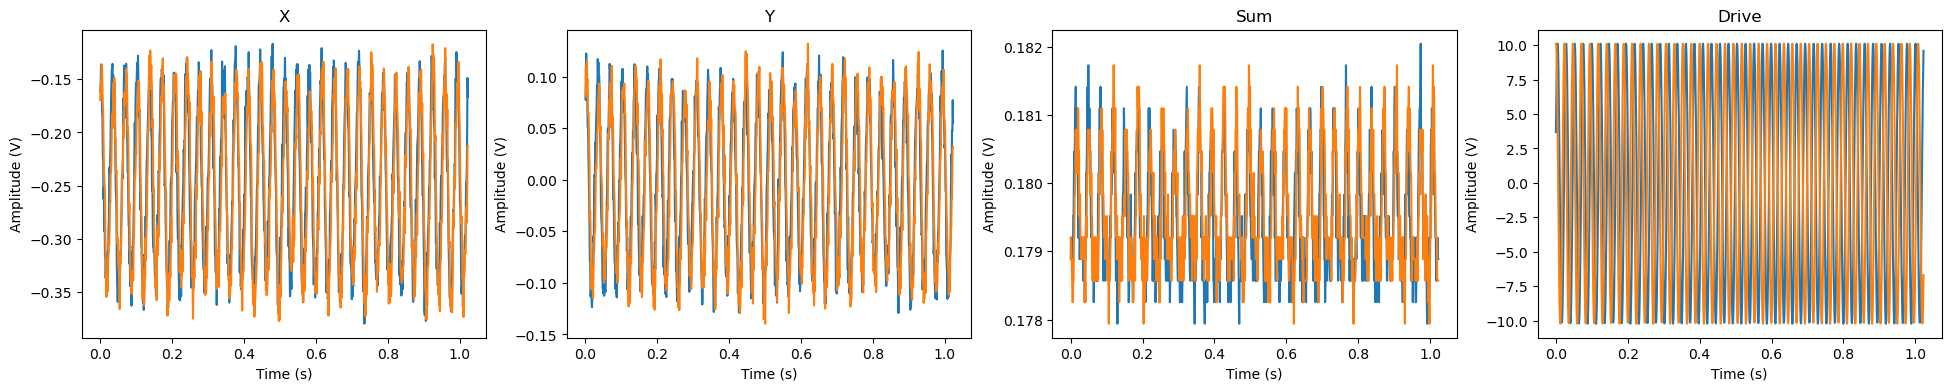

In [56]:
data, totSkip = lj.read_analog_in(num_scans=num_traces_per_file)

if(totSkip > 0):
    print("Warning: Skipped {} samples".format(totSkip))

if(save_data):
    filename = output_path + "transfer_func_data_%.2fHz_to_%.2fHz_%.2fV.npz"%(sweep_start_freq, sweep_stop_freq, sweep_amplitude)
    np.savez(filename, data = data, Fs=sampling_rate, sweep_start_freq=sweep_start_freq, sweep_stop_freq=sweep_stop_freq, sweep_amplitude=sweep_amplitude)

if(plot_data):
    ## plot data
    time_vec = np.arange(num_samples)/sampling_rate

    plt.figure(figsize=(6*num_channels,4))
    for i in range(num_traces_per_file):
        for ch in range(num_channels):
            plt.subplot(1,num_channels,ch+1)
            plt.plot(time_vec, data[i][:,ch])
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude (V)")
            plt.title(ch_names[ch])
    plt.show()

lj.close()